# Flow Matching — MNIST Warmup

This notebook walks through the full flow matching pipeline on MNIST,
using the reusable `genailab.flow_matching` package.

It is intentionally kept small (MPS-safe) and visual:
- We use a tiny U-Net (`base_channels=32`) and train for only a few epochs
- Every key object is inspected to build intuition
- We visualise training trajectories and generated samples

For a full-scale run, see `examples/flow_matching/01_mnist_flow_matching.py`.

**Concepts covered:**
1. The linear interpolant $\psi_t = (1-t)x_0 + t x_1$ and velocity $u_t = x_1 - x_0$
2. Building and inspecting the velocity U-Net
3. One manual training step — making the CFM loss concrete
4. Full training with `FlowMatchingTrainer`
5. Euler sampling: integrating backward from $t=1$ to $t=0$
6. Visualising sample quality and flow trajectories

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add src/ to path so genailab is importable from the notebook
repo_root = Path("../..").resolve()
sys.path.insert(0, str(repo_root / "src"))

import torch
import matplotlib.pyplot as plt
import numpy as np

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: cuda


## 1. The Interpolant — Making $x_t$ Concrete

The `LinearInterpolant` defines:
- **Path**: $x_t = (1-t)\, x_0 + t\, x_1$
- **Velocity target**: $u_t = x_1 - x_0$ (constant, does not depend on $t$)

Let's inspect it on a single pair before involving any neural network.

In [2]:
from genailab.flow_matching import LinearInterpolant, broadcast_time

interp = LinearInterpolant()

# Fake a batch of 4 single-channel 28x28 images
B, C, H, W = 4, 1, 28, 28
x0 = torch.zeros(B, C, H, W)   # data (black image)
x1 = torch.ones(B, C, H, W)    # noise (white image)

for t_val in [0.0, 0.25, 0.5, 0.75, 1.0]:
    t = broadcast_time(torch.full((B,), t_val), x0)
    xt = interp.interpolate(x0, x1, t)
    ut = interp.velocity(x0, x1, t)
    print(f"t={t_val:.2f}  x_t mean={xt.mean():.2f}  u_t mean={ut.mean():.2f} (constant)")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


t=0.00  x_t mean=0.00  u_t mean=1.00 (constant)
t=0.25  x_t mean=0.25  u_t mean=1.00 (constant)
t=0.50  x_t mean=0.50  u_t mean=1.00 (constant)
t=0.75  x_t mean=0.75  u_t mean=1.00 (constant)
t=1.00  x_t mean=1.00  u_t mean=1.00 (constant)


Note that `u_t` is the same at every `t` — it is always `x1 - x0 = 1 - 0 = 1`.
This is the hallmark of rectified flow: **constant velocity along each straight-line path**.

## 2. Data — Load MNIST

In [3]:
from genailab.flow_matching import get_mnist_dataloader

train_loader = get_mnist_dataloader(batch_size=128, image_size=28, split="train")
val_loader   = get_mnist_dataloader(batch_size=128, image_size=28, split="test")

# Inspect a batch
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")
print(f"Value range : [{images.min():.2f}, {images.max():.2f}]  (should be [-1, 1])")
print(f"Labels      : {labels[:8].tolist()}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 78.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.59MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 20.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.13MB/s]


Batch shape : torch.Size([128, 1, 28, 28])
Value range : [-1.00, 1.00]  (should be [-1, 1])
Labels      : [6, 8, 9, 8, 9, 3, 8, 3]


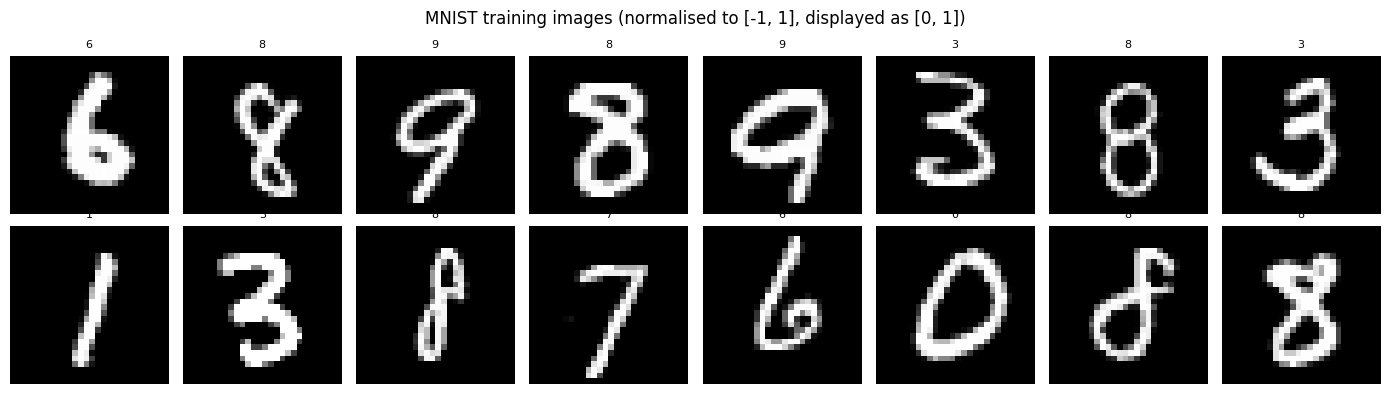

In [4]:
# Visualise a few training images (rescaled to [0,1] for display)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow((images[i, 0] + 1) / 2, cmap="gray", vmin=0, vmax=1)
    ax.set_title(labels[i].item(), fontsize=8)
    ax.axis("off")
plt.suptitle("MNIST training images (normalised to [-1, 1], displayed as [0, 1])")
plt.tight_layout()
plt.show()

## 3. The Velocity Network

In [5]:
from genailab.flow_matching import VelocityUNet2D

# Small model — MPS-safe (32 base channels)
# For RunPod: increase to base_channels=128
model = VelocityUNet2D(
    in_channels=1,
    base_channels=32,
    channel_multipliers=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=128,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,} ({n_params/1e6:.2f}M)")

# Test forward pass: input x_t and time t → predicted velocity
x_test = torch.randn(4, 1, 28, 28, device=device)
t_test = torch.rand(4, device=device)
v_pred = model(x_test, t_test)
print(f"Input shape : {x_test.shape}")
print(f"Output shape: {v_pred.shape}  (same as input — predicted velocity)")

Parameters: 3,280,705 (3.28M)
Input shape : torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 1, 28, 28])  (same as input — predicted velocity)


## 4. One Manual Training Step

Before using the trainer, let's manually construct one CFM training example
to make the loss completely concrete.

Recall the five objects in each training example:

| Object | What it is | Role |
|--------|-----------|------|
| $x_0$ | Real MNIST image | Path start (data) |
| $x_1$ | Gaussian noise | Path end (noise) |
| $t$ | Uniform random time | Where along the path |
| $x_t = (1-t)x_0 + tx_1$ | Interpolated image | Network input |
| $u_t = x_1 - x_0$ | Conditional velocity | Regression target |

In [6]:
from genailab.flow_matching import cfm_loss

# One batch from the dataloader
x0_batch, _ = next(iter(train_loader))
x0_batch = x0_batch.to(device)
x1_batch = torch.randn_like(x0_batch)  # N(0, I) noise

# Manual decomposition — mirrors cfm_loss() internals
B = x0_batch.shape[0]
t_scalar = torch.rand(B, device=device)          # (B,)  uniform in [0,1]
t        = broadcast_time(t_scalar, x0_batch)    # (B,1,1,1)  for broadcast

x_t = (1.0 - t) * x0_batch + t * x1_batch       # interpolated input
u_t = x1_batch - x0_batch                        # velocity target

v_pred = model(x_t, t_scalar)                    # network prediction
loss   = ((v_pred - u_t) ** 2).mean()

print(f"t range       : [{t_scalar.min():.2f}, {t_scalar.max():.2f}]")
print(f"x_t   shape   : {x_t.shape}")
print(f"u_t   shape   : {u_t.shape}")
print(f"v_pred shape  : {v_pred.shape}")
print(f"CFM loss      : {loss.item():.4f}  (untrained → large)")

# Confirm cfm_loss() gives the same value
loss_fn = cfm_loss(model, x0_batch, interp, x1_batch)
print(f"cfm_loss()    : {loss_fn.item():.4f}  (same up to rng differences)")

t range       : [0.01, 1.00]
x_t   shape   : torch.Size([128, 1, 28, 28])
u_t   shape   : torch.Size([128, 1, 28, 28])
v_pred shape  : torch.Size([128, 1, 28, 28])
CFM loss      : 2.0754  (untrained → large)
cfm_loss()    : 2.0831  (same up to rng differences)


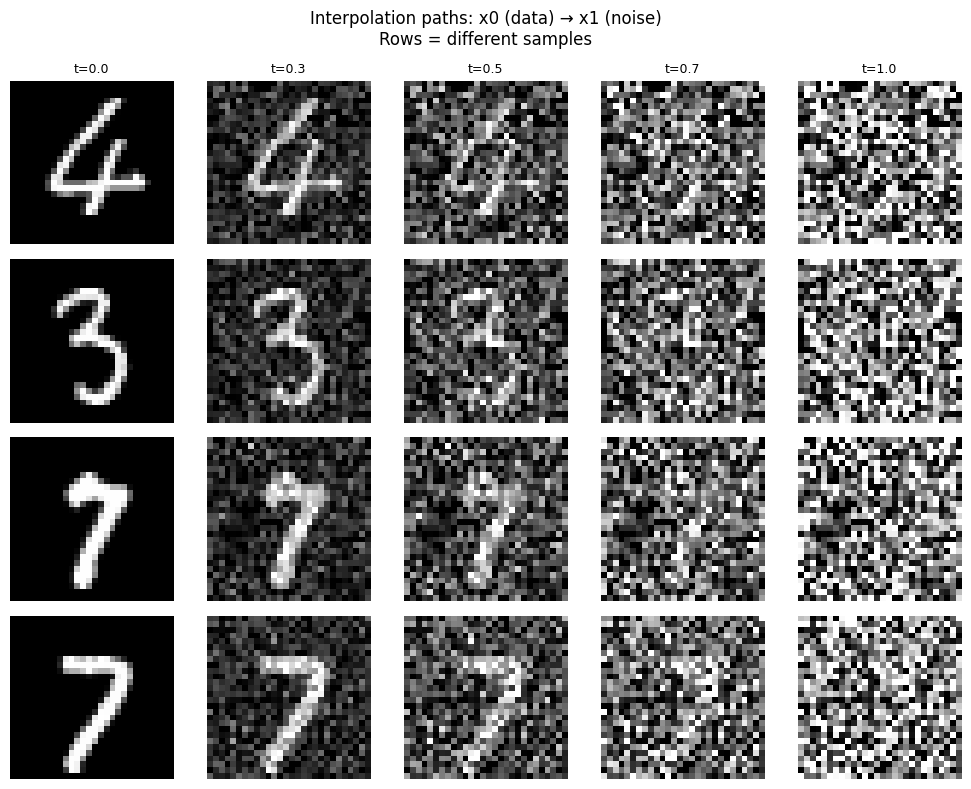

In [7]:
# Visualise: data x0, noise x1, interpolated x_t at t=0.3 and t=0.7
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
t_vals = [0.0, 0.3, 0.5, 0.7, 1.0]

for row in range(4):
    x0_i = x0_batch[row]  # (1, 28, 28)
    x1_i = x1_batch[row]
    for col, tv in enumerate(t_vals):
        xt_i = (1 - tv) * x0_i + tv * x1_i
        ax = axes[row, col]
        ax.imshow((xt_i[0].cpu().clamp(-1,1) + 1) / 2, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"t={tv:.1f}", fontsize=9)

plt.suptitle("Interpolation paths: x0 (data) → x1 (noise)\nRows = different samples")
plt.tight_layout()
plt.show()

## 5. Training

We train for a small number of epochs to keep this notebook fast.
Even 20-30 epochs produces recognisable digit shapes on MNIST with a small model.

For a full-quality run: `python examples/flow_matching/01_mnist_flow_matching.py --epochs 200`

In [8]:
from genailab.flow_matching import FlowMatchingTrainer
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s", datefmt="%H:%M:%S")

EPOCHS = 30  # increase to 200+ for production quality

trainer = FlowMatchingTrainer(
    model=model,
    interpolant=LinearInterpolant(),
    lr=1e-4,
    checkpoint_dir="runs/mnist_nb",
    checkpoint_every=10,
)

history = trainer.fit(
    train_loader=train_loader,
    epochs=EPOCHS,
    val_loader=val_loader,
)

17:45:18  Training on cuda for 30 epochs (lr=1.00e-04)
17:45:53  Epoch    1/30  train_loss=0.3402  val_loss=0.2320            
17:46:28  Epoch    2/30  train_loss=0.2232  val_loss=0.2112            
17:47:03  Epoch    3/30  train_loss=0.2084  val_loss=0.2042            
17:47:38  Epoch    4/30  train_loss=0.2007  val_loss=0.1971            
17:48:13  Epoch    5/30  train_loss=0.1955  val_loss=0.1913            
17:48:50  Epoch    6/30  train_loss=0.1923  val_loss=0.1903            
17:49:26  Epoch    7/30  train_loss=0.1892  val_loss=0.1874            
17:50:02  Epoch    8/30  train_loss=0.1868  val_loss=0.1856            
17:50:39  Epoch    9/30  train_loss=0.1850  val_loss=0.1823            
17:51:14  Epoch   10/30  train_loss=0.1836  val_loss=0.1846            
17:51:14  Checkpoint saved: runs/mnist_nb/checkpoint_epoch0010.pt
17:51:50  Epoch   11/30  train_loss=0.1828  val_loss=0.1814            
17:52:23  Epoch   12/30  train_loss=0.1811  val_loss=0.1814            
17:52:58  Epoch

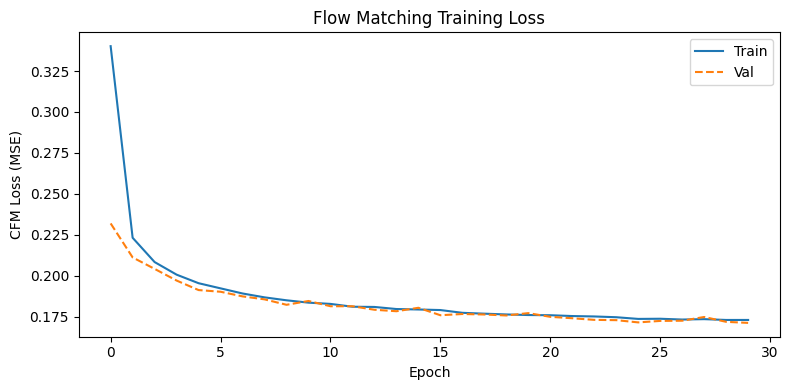

In [9]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_loss"], label="Train")
if history["val_loss"]:
    ax.plot(history["val_loss"], label="Val", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("CFM Loss (MSE)")
ax.set_title("Flow Matching Training Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sampling — Euler Integration

To generate samples, we integrate the learned ODE backward from $t=1$ (noise) to $t=0$ (data):

$$x_{t - \Delta t} = x_t - \Delta t \cdot v_\theta(x_t,\, t)$$

Each call to $v_\theta$ is one NFE. With 50 steps we use 50 NFEs.

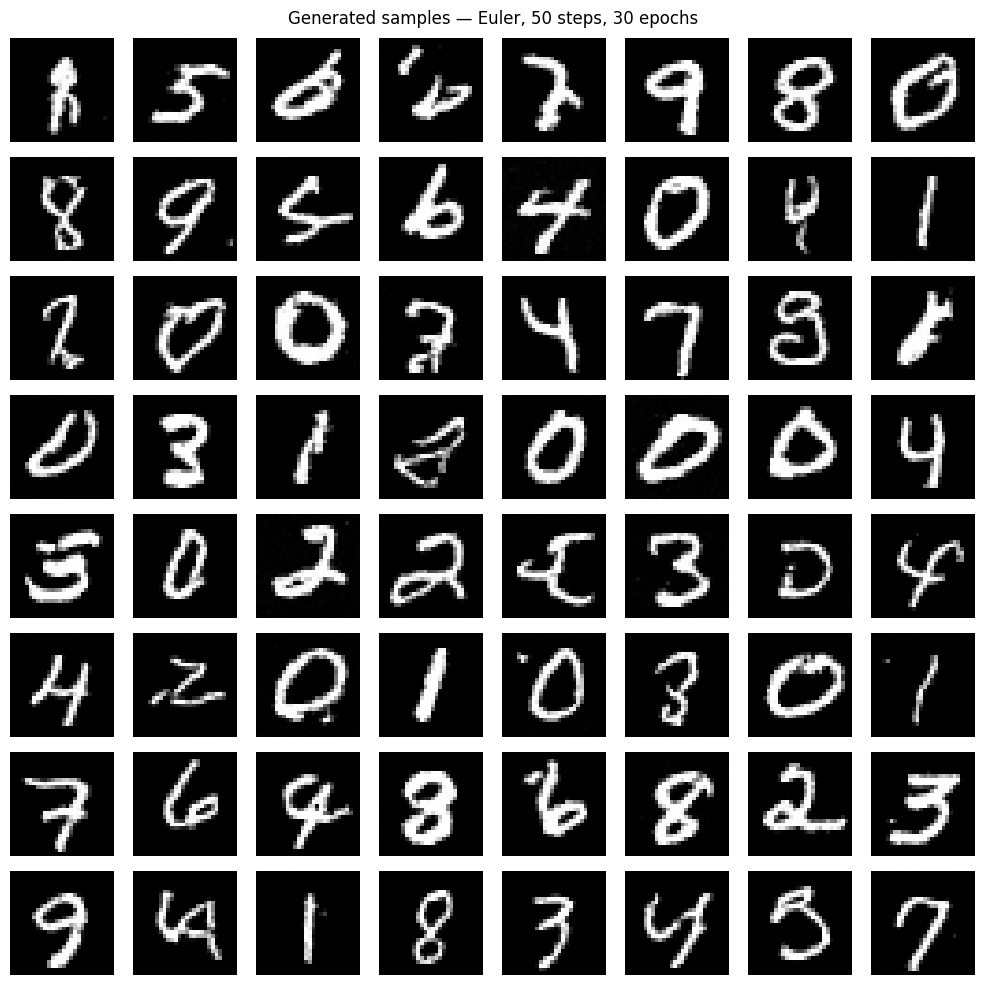

In [10]:
from genailab.flow_matching import EulerSampler

sampler = EulerSampler(model, n_steps=50)
samples = sampler.sample(n=64, image_shape=(1, 28, 28))

# Rescale [-1,1] → [0,1] for display
samples_display = (samples.clamp(-1, 1) + 1.0) / 2.0

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_display[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle(f"Generated samples — Euler, 50 steps, {EPOCHS} epochs")
plt.tight_layout()
plt.show()

## 7. Trajectory Visualisation

Let's trace a few samples through their integration path to see
how the ODE deforms noise into digits.

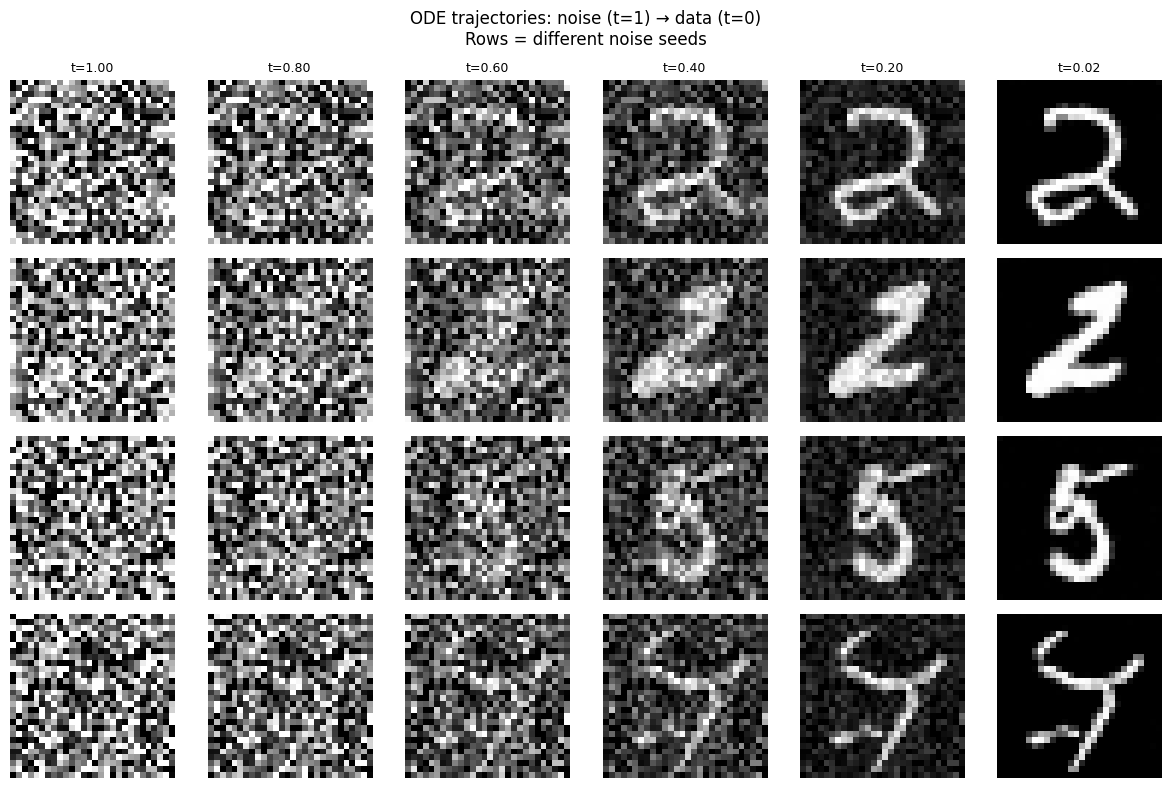

In [11]:
from genailab.flow_matching.interpolants import broadcast_time

N_TRAJ = 4       # number of trajectories to visualise
N_STEPS = 50
SHOW_AT  = [0, 10, 20, 30, 40, 49]  # steps to visualise

model.eval()
x = torch.randn(N_TRAJ, 1, 28, 28, device=device)
snapshots = {s: None for s in SHOW_AT}
dt = 1.0 / N_STEPS

with torch.no_grad():
    for step in range(N_STEPS):
        if step in snapshots:
            snapshots[step] = x.cpu().clone()
        t = 1.0 - step * dt
        t_tensor = torch.full((N_TRAJ,), t, device=device)
        x = x - dt * model(x, t_tensor)
    snapshots[N_STEPS - 1] = x.cpu().clone()  # final

fig, axes = plt.subplots(N_TRAJ, len(SHOW_AT), figsize=(len(SHOW_AT) * 2, N_TRAJ * 2))
for row in range(N_TRAJ):
    for col, step in enumerate(SHOW_AT):
        img = (snapshots[step][row, 0].clamp(-1, 1) + 1) / 2
        axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            t_at_step = 1.0 - step * dt
            axes[row, col].set_title(f"t={t_at_step:.2f}", fontsize=9)

plt.suptitle("ODE trajectories: noise (t=1) → data (t=0)\nRows = different noise seeds")
plt.tight_layout()
plt.show()

## 8. Step-Count Ablation

How few steps can we use before quality degrades? 
This gives intuition for the straight-path advantage of rectified flow.

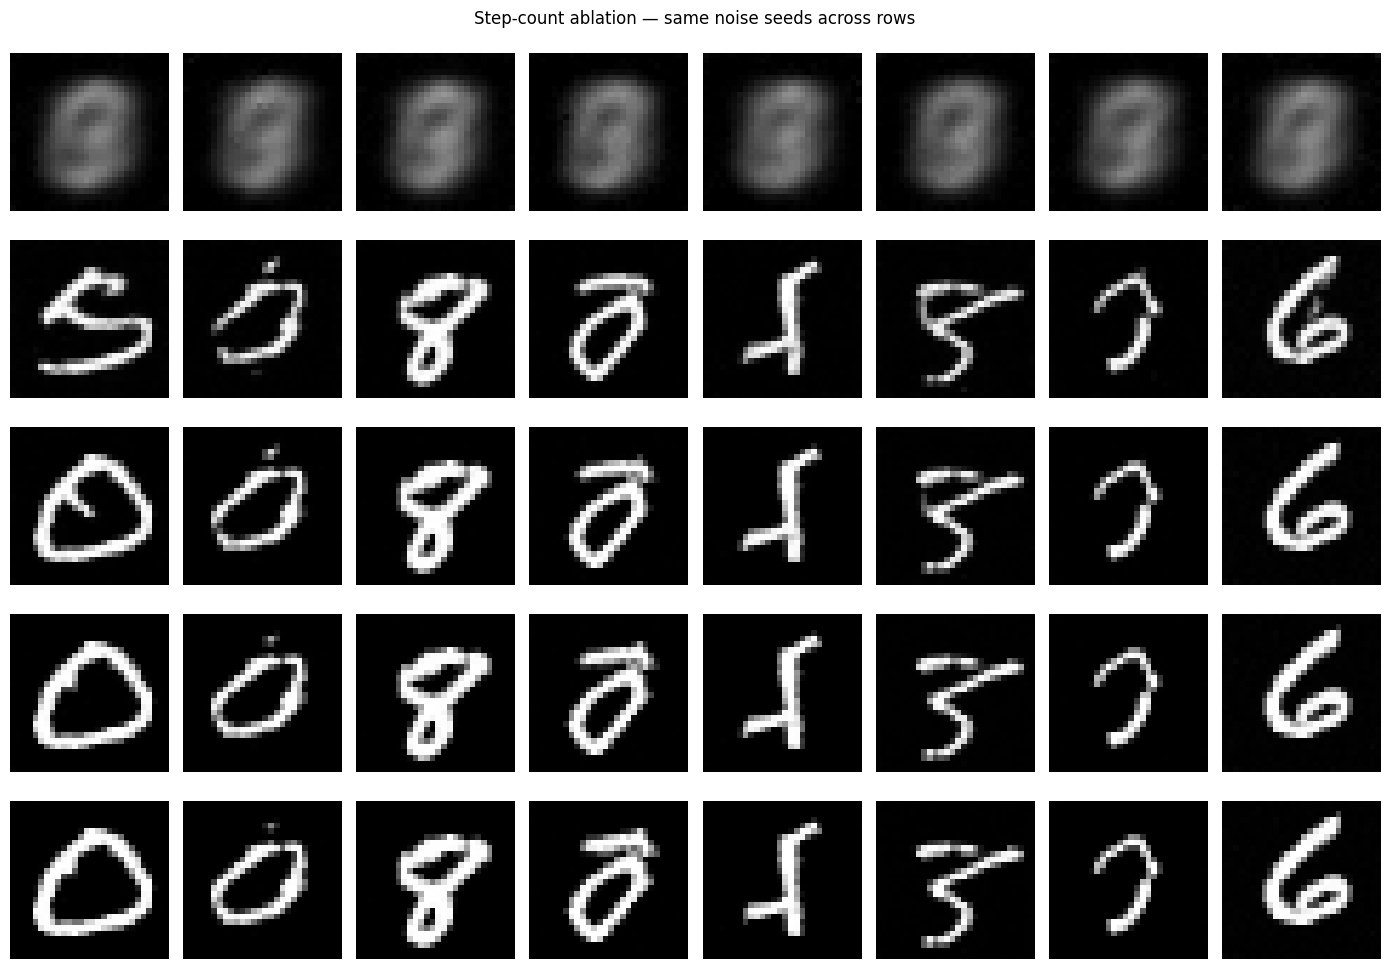

In [12]:
from genailab.flow_matching import EulerSampler

step_counts = [1, 5, 10, 20, 50]

# Fix the noise seed so we compare the same starting points
torch.manual_seed(42)
fixed_noise = torch.randn(8, 1, 28, 28, device=device)

fig, axes = plt.subplots(len(step_counts), 8, figsize=(14, len(step_counts) * 2))

for row, n_steps in enumerate(step_counts):
    # Run Euler with this noise
    x = fixed_noise.clone()
    dt = 1.0 / n_steps
    model.eval()
    with torch.no_grad():
        for step in range(n_steps):
            t = 1.0 - step * dt
            t_tensor = torch.full((8,), t, device=device)
            x = x - dt * model(x, t_tensor)

    x_disp = (x.clamp(-1, 1) + 1) / 2
    for col in range(8):
        axes[row, col].imshow(x_disp[col, 0].cpu(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"{n_steps} steps\n({n_steps} NFEs)", fontsize=9)

plt.suptitle("Step-count ablation — same noise seeds across rows")
plt.tight_layout()
plt.show()

## Summary

| Component | What it does | Key design choice |
|-----------|-------------|------------------|
| `LinearInterpolant` | Defines straight-line paths $x_t = (1-t)x_0 + tx_1$ | Constant velocity $u_t = x_1 - x_0$ |
| `VelocityUNet2D` | Predicts $v_\theta(x_t, t)$ | U-Net with sinusoidal time embedding + FiLM |
| `cfm_loss` | MSE between prediction and target | Tractable via conditional expectation property |
| `FlowMatchingTrainer` | Training loop + checkpointing | AdamW + cosine LR schedule |
| `EulerSampler` | Backward ODE integration | 50 steps ≈ 50 NFEs |

**Next steps:**
- Scale to PathMNIST (colorectal cancer histology) → `examples/flow_matching/02_pathmnist_synthesis.py`
- Try `RK4Sampler(n_steps=20)` for 4× NFE reduction at comparable quality
- Conditional generation with classifier-free guidance
- Reflow: iterative path-straightening for even fewer sampling steps